<a href="https://colab.research.google.com/github/krithi-ks/PetroVision/blob/main/notebooks/computer-vision/PetroVision_DeepLabV3Plus_FineTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PetroVision — DeepLabV3+ Fine-Tuning Experiment

**Experiment ID:** CV-DEEPLAB-001

This experiment fine-tunes a pretrained DeepLabV3+ segmentation model
on the LADOS dataset for binary petroleum-related visual contamination
segmentation.

The experiment is compared with the PetroVision U-Net baseline under
a controlled evaluation setup.

## Install dependency

In [20]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 1.9 MB/s eta 0:00:00


## Imports and device

In [21]:
import os
import sys
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import segmentation_models_pytorch as smp

print("PyTorch:", torch.__version__)
print("SMP:", smp.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch: 2.11.0+cu128
SMP: 0.5.0
CUDA available: True
Device: cuda


## Drive + project

In [29]:
!git clone https://github.com/krithi-ks/PetroVision.git /content/PetroVision
%cd /content/PetroVision

from pathlib import Path

print("Project root:", Path.cwd())
print("\nProject files:")
for item in sorted(Path(".").iterdir()):
    print(" -", item.name)

fatal: destination path '/content/PetroVision' already exists and is not an empty directory.
/content/PetroVision
Project root: /content/PetroVision

Project files:
 - .git
 - .gitignore
 - README.md
 - app
 - data
 - docs
 - models
 - notebooks
 - references
 - reports
 - requirements.txt
 - results
 - src


In [30]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
PROJECT_DIR = "/content/PetroVision"
sys.path.insert(0, PROJECT_DIR)

DRIVE_ROOT = "/content/drive/MyDrive/PetroVision"

MODEL_DIR = os.path.join(DRIVE_ROOT, "models")
RESULT_DIR = os.path.join(DRIVE_ROOT, "results", "cv_deeplab_001")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Results:", RESULT_DIR)

Project: /content/PetroVision
Results: /content/drive/MyDrive/PetroVision/results/cv_deeplab_001


In [32]:
from pathlib import Path
import zipfile

ZIP_PATH = Path(
    "/content/drive/MyDrive/PetroVision/datasets/"
    "PetroVision.v1i.png-mask-semantic.zip"
)

EXTRACT_DIR = Path("/content/PetroVision/data/lados")

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset ZIP not found: {ZIP_PATH}")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted to:", EXTRACT_DIR)


Dataset extracted to: /content/PetroVision/data/lados


## Verify dataset and source modules

In [33]:
from src.vision.lados_dataset import LADOSDataset
from src.vision.segmentation_loss import BCEDiceLoss

DATASET_ROOT = os.path.join(PROJECT_DIR, "data", "lados")

print("Dataset exists:", os.path.exists(DATASET_ROOT))
print("Source module loaded successfully.")

Dataset exists: True
Source module loaded successfully.


## Dataset

In [39]:
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 16

train_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="train",
    image_size=IMAGE_SIZE,
    augment=True
)

valid_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="valid",
    image_size=IMAGE_SIZE,
    augment=False
)

test_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="test",
    image_size=IMAGE_SIZE,
    augment=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train:", len(train_dataset))
print("Validation:", len(valid_dataset))
print("Test:", len(test_dataset))

Train: 2370
Validation: 675
Test: 343


## Create DeepLabV3+

In [66]:
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(device)

criterion = BCEDiceLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("DeepLabV3+ model and optimizer ready.")
print("Trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

DeepLabV3+ model and optimizer ready.
Trainable parameters: 26677585


## Loss and optimizer

In [65]:
criterion = BCEDiceLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Optimizer Created.")

Optimizer Created.


In [67]:
model_param = next(model.parameters())
optimizer_param = optimizer.param_groups[0]["params"][0]

print("Same parameter object:", model_param is optimizer_param)

Same parameter object: True


In [68]:
# Check whether gradients and optimizer updates are actually occurring

model.train()

images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

optimizer.zero_grad()

outputs = model(images)

if isinstance(outputs, dict):
    outputs = outputs["out"]

loss = criterion(outputs, masks)
loss.backward()

# Gradient check
grad_values = []

for name, param in model.named_parameters():
    if param.requires_grad and param.grad is not None:
        grad_values.append({
            "name": name,
            "grad_mean": param.grad.abs().mean().item(),
            "grad_max": param.grad.abs().max().item()
        })

print("Loss:", loss.item())
print("Parameters with gradients:", len(grad_values))

print("\nFirst 10 gradient values:")
for item in grad_values[:10]:
    print(
        item["name"],
        "| mean:", f'{item["grad_mean"]:.10e}',
        "| max:", f'{item["grad_max"]:.10e}'
    )

# Save parameters before optimizer step
params_before = {
    name: param.detach().clone()
    for name, param in model.named_parameters()
    if param.requires_grad
}

optimizer.step()

# Measure actual updates across all parameters
updates = []

for name, param in model.named_parameters():
    if param.requires_grad:
        change = torch.abs(param.detach() - params_before[name])

        updates.append({
            "name": name,
            "mean_change": change.mean().item(),
            "max_change": change.max().item()
        })

print("\nParameter updates:")
for item in updates[:10]:
    print(
        item["name"],
        "| mean:", f'{item["mean_change"]:.10e}',
        "| max:", f'{item["max_change"]:.10e}'
    )

print("\nMaximum parameter update:",
      max(x["max_change"] for x in updates))

Loss: 0.5573424696922302
Parameters with gradients: 193

First 10 gradient values:
encoder.conv1.weight | mean: 3.3463286236e-03 | max: 3.8499176502e-02
encoder.bn1.weight | mean: 6.5106772818e-03 | max: 3.3242873847e-02
encoder.bn1.bias | mean: 8.8093755767e-04 | max: 6.1602108181e-03
encoder.layer1.0.conv1.weight | mean: 1.3547902927e-03 | max: 2.0446347073e-02
encoder.layer1.0.bn1.weight | mean: 3.4478716552e-03 | max: 1.3829883188e-02
encoder.layer1.0.bn1.bias | mean: 2.5097157340e-03 | max: 1.3983195648e-02
encoder.layer1.0.conv2.weight | mean: 4.0467290091e-04 | max: 6.2626414001e-03
encoder.layer1.0.bn2.weight | mean: 3.7978070322e-03 | max: 1.2152813375e-02
encoder.layer1.0.bn2.bias | mean: 1.7897152575e-03 | max: 1.0177968070e-02
encoder.layer1.0.conv3.weight | mean: 4.5370892622e-04 | max: 6.4206002280e-03

Parameter updates:
encoder.conv1.weight | mean: 9.8433483799e-05 | max: 1.0001659393e-04
encoder.bn1.weight | mean: 9.8433112726e-05 | max: 1.0001659393e-04
encoder.bn1.bi

In [69]:
print("Optimizer:", type(optimizer).__name__)

for i, group in enumerate(optimizer.param_groups):
    print(f"\nParameter group {i}")
    print("Learning rate:", group["lr"])
    print("Weight decay:", group.get("weight_decay"))
    print("Number of parameters:", len(group["params"]))

print("\nModel parameters requiring gradients:",
      sum(p.requires_grad for p in model.parameters()))

print("Optimizer parameters:",
      sum(len(group["params"]) for group in optimizer.param_groups))

Optimizer: Adam

Parameter group 0
Learning rate: 0.0001
Weight decay: 0
Number of parameters: 193

Model parameters requiring gradients: 193
Optimizer parameters: 193


In [70]:
with torch.no_grad():
    probabilities = torch.sigmoid(outputs)

print("Logit min:", outputs.min().item())
print("Logit max:", outputs.max().item())
print("Probability min:", probabilities.min().item())
print("Probability max:", probabilities.max().item())
print("Prediction mean:", probabilities.mean().item())
print("Target mean:", masks.float().mean().item())

Logit min: -1.5607056617736816
Logit max: 2.6954879760742188
Probability min: 0.17354540526866913
Probability max: 0.936759889125824
Prediction mean: 0.5962541699409485
Target mean: 0.6260280609130859


## Evaluation Helper

In [71]:
def calculate_metrics(model, loader, threshold=0.5):
    model.eval()

    tp = fp = fn = tn = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(images)
            probabilities = torch.sigmoid(logits)
            predictions = probabilities >= threshold
            targets = masks >= 0.5

            tp += torch.logical_and(predictions, targets).sum().item()
            fp += torch.logical_and(predictions, ~targets).sum().item()
            fn += torch.logical_and(~predictions, targets).sum().item()
            tn += torch.logical_and(~predictions, ~targets).sum().item()

    eps = 1e-8

    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    accuracy = (tp + tn) / (tp + fp + fn + tn + eps)

    return {
        "IoU": iou,
        "Dice": dice,
        "Precision": precision,
        "Recall": recall,
        "Accuracy": accuracy,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    }

## Training

In [73]:
history = {
    "train_loss": [],
    "validation_loss": []
}

best_val_loss = float("inf")
best_epoch = None

checkpoint_path = os.path.join(
    MODEL_DIR,
    "cv_deeplab_001_best.pt"
)

for epoch in range(1, NUM_EPOCHS + 1):

    model.train()
    train_loss_total = 0.0

    for images, masks in train_loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        train_loss_total += loss.item()

    train_loss = train_loss_total / len(train_loader)

    model.eval()
    validation_loss_total = 0.0

    with torch.no_grad():
        for images, masks in valid_loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, masks)

            validation_loss_total += loss.item()

    validation_loss = validation_loss_total / len(valid_loader)

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)

    if validation_loss < best_val_loss:
        best_val_loss = validation_loss
        best_epoch = epoch

        torch.save({
            "experiment_id": "CV-DEEPLAB-001",
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "validation_loss": validation_loss
        }, checkpoint_path)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {validation_loss:.6f}"
    )

print("\nTraining completed.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Checkpoint:", checkpoint_path)

Epoch 01/20 | Train Loss: 0.159058 | Validation Loss: 0.261248
Epoch 02/20 | Train Loss: 0.157107 | Validation Loss: 0.306995
Epoch 03/20 | Train Loss: 0.154475 | Validation Loss: 0.286225
Epoch 04/20 | Train Loss: 0.143510 | Validation Loss: 0.268714
Epoch 05/20 | Train Loss: 0.147974 | Validation Loss: 0.278232
Epoch 06/20 | Train Loss: 0.135388 | Validation Loss: 0.292450
Epoch 07/20 | Train Loss: 0.142144 | Validation Loss: 0.293431
Epoch 08/20 | Train Loss: 0.138723 | Validation Loss: 0.288140
Epoch 09/20 | Train Loss: 0.140272 | Validation Loss: 0.261508
Epoch 10/20 | Train Loss: 0.129338 | Validation Loss: 0.271028
Epoch 11/20 | Train Loss: 0.136327 | Validation Loss: 0.273064
Epoch 12/20 | Train Loss: 0.129571 | Validation Loss: 0.294855
Epoch 13/20 | Train Loss: 0.135193 | Validation Loss: 0.281063
Epoch 14/20 | Train Loss: 0.130869 | Validation Loss: 0.288394
Epoch 15/20 | Train Loss: 0.125758 | Validation Loss: 0.280061
Epoch 16/20 | Train Loss: 0.119294 | Validation Loss: 0

## Save training history

In [74]:
history_path = os.path.join(
    RESULT_DIR,
    "training_history.json"
)

with open(history_path, "w") as f:
    json.dump(
        {
            "experiment_id": "CV-DEEPLAB-001",
            "best_epoch": best_epoch,
            "best_validation_loss": best_val_loss,
            **history
        },
        f,
        indent=2
    )

print("Saved:", history_path)

Saved: /content/drive/MyDrive/PetroVision/results/cv_deeplab_001/training_history.json


## Training curves

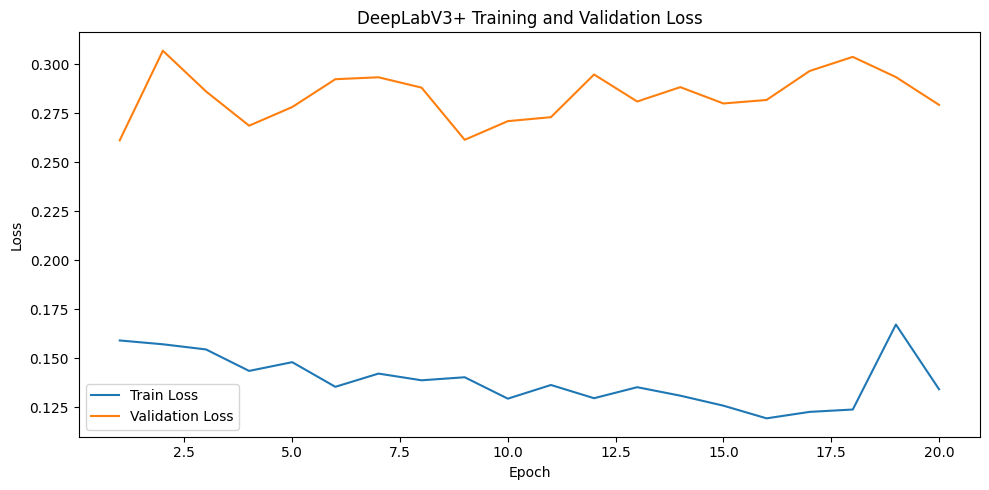

In [75]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["validation_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DeepLabV3+ Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

## Load best checkpoints

In [76]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded best checkpoint from epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["validation_loss"])

Loaded best checkpoint from epoch: 1
Validation loss: 0.2612480165999989


## Test evaluation

In [77]:
test_metrics = calculate_metrics(
    model,
    test_loader,
    threshold=0.5
)

test_metrics = {
    "experiment_id": "CV-DEEPLAB-001",
    "architecture": "DeepLabV3+",
    "encoder": "ResNet-50",
    "encoder_initialization": "ImageNet pretrained",
    "image_size": IMAGE_SIZE,
    "threshold": 0.5,
    "best_epoch": best_epoch,
    "validation_loss": best_val_loss,
    **test_metrics
}

print(json.dumps(test_metrics, indent=2))

{
  "experiment_id": "CV-DEEPLAB-001",
  "architecture": "DeepLabV3+",
  "encoder": "ResNet-50",
  "encoder_initialization": "ImageNet pretrained",
  "image_size": [
    256,
    256
  ],
  "threshold": 0.5,
  "best_epoch": 1,
  "validation_loss": 0.2612480165999989,
  "IoU": 0.8201093165594036,
  "Dice": 0.901164901578193,
  "Precision": 0.8946386801668657,
  "Recall": 0.907787037792853,
  "Accuracy": 0.8939767287006875,
  "TP": 10865215,
  "FP": 1279593,
  "FN": 1103688,
  "TN": 9230352
}


## Save test metrics

In [78]:
metrics_path = os.path.join(
    RESULT_DIR,
    "test_metrics.json"
)

with open(metrics_path, "w") as f:
    json.dump(test_metrics, f, indent=2)

print("Saved:", metrics_path)

Saved: /content/drive/MyDrive/PetroVision/results/cv_deeplab_001/test_metrics.json


## Metric visualization

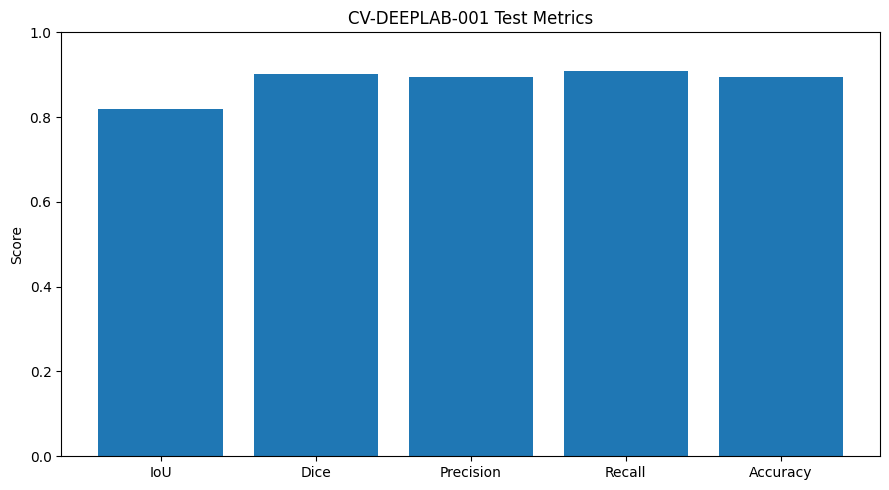

In [79]:
metric_names = [
    "IoU",
    "Dice",
    "Precision",
    "Recall",
    "Accuracy"
]

metric_values = [
    test_metrics[name]
    for name in metric_names
]

plt.figure(figsize=(9, 5))
plt.bar(metric_names, metric_values)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("CV-DEEPLAB-001 Test Metrics")
plt.tight_layout()
plt.show()

## Qualitative Predictions

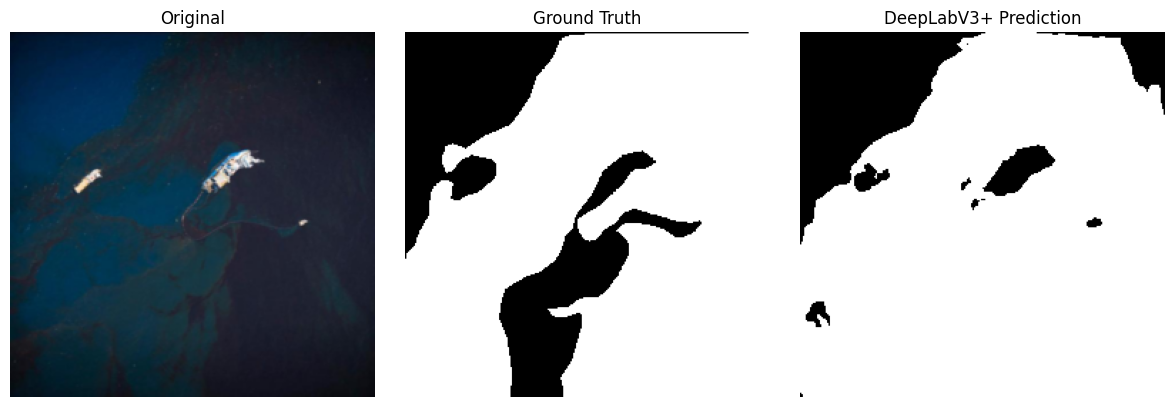

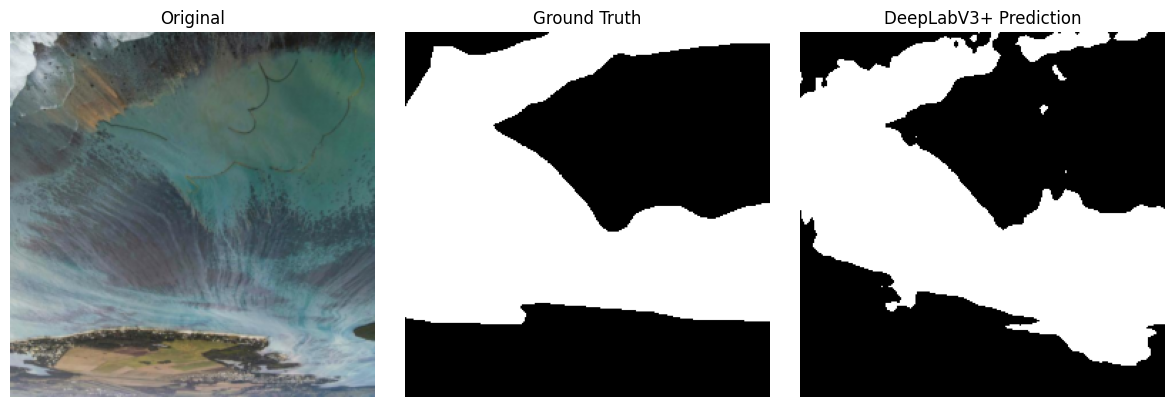

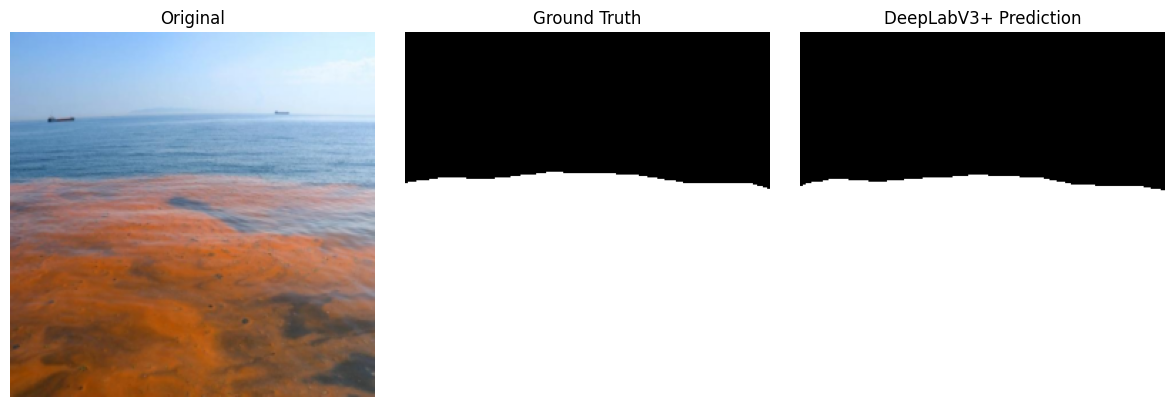

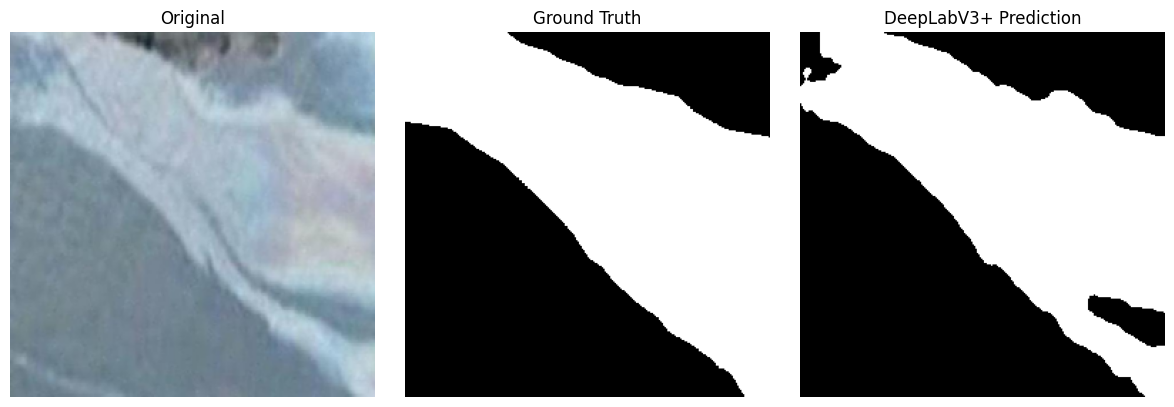

In [80]:
model.eval()

images, masks = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():
    logits = model(images_device)
    probabilities = torch.sigmoid(logits)

predictions = (probabilities >= 0.5).float()

num_examples = min(4, len(images))

for i in range(num_examples):
    image = images[i].permute(1, 2, 0).numpy()
    ground_truth = masks[i].squeeze().numpy()
    prediction = predictions[i].cpu().squeeze().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(image)
    axes[0].set_title("Original")

    axes[1].imshow(ground_truth, cmap="gray")
    axes[1].set_title("Ground Truth")

    axes[2].imshow(prediction, cmap="gray")
    axes[2].set_title("DeepLabV3+ Prediction")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## CV-DEEPLAB-001 — Experiment Summary

### What was tested
A pretrained DeepLabV3+ segmentation architecture was fine-tuned on the LADOS dataset.

### Why it was needed
This experiment evaluates whether a different segmentation architecture can provide useful performance compared with the PetroVision U-Net baseline.

### What was changed
The segmentation architecture was changed from U-Net to DeepLabV3+ with an ImageNet-pretrained ResNet-50 encoder.

### What was kept constant
The LADOS dataset, dataset split, binary petroleum target, image resolution, training augmentation policy, evaluation threshold, and evaluation metrics were kept consistent with the controlled comparison setup where applicable.

### Actual result
The numerical results below are generated automatically from the completed experiment.

### Limitation
The result is specific to the evaluated dataset, architecture configuration, pretrained initialization, training configuration, and computational setup.

### Output files
- Best model checkpoint
- Training history
- Test metrics
- Experiment summary

### Next stage
The DeepLabV3+ results will be compared with the PetroVision U-Net experiments before deciding whether an additional architecture such as SegFormer is warranted.

In [81]:
summary_record = {
    "experiment_id": "CV-DEEPLAB-001",
    "what_was_tested": "Pretrained DeepLabV3+ fine-tuned on LADOS",
    "architecture": "DeepLabV3+",
    "encoder": "ResNet-50",
    "initialization": "ImageNet pretrained",
    "best_epoch": test_metrics["best_epoch"],
    "validation_loss": test_metrics["validation_loss"],
    "test_metrics": {
        key: test_metrics[key]
        for key in [
            "IoU",
            "Dice",
            "Precision",
            "Recall",
            "Accuracy"
        ]
    },
    "limitation": (
        "Results are specific to the evaluated LADOS dataset, "
        "architecture configuration, pretrained initialization, "
        "and training setup."
    )
}

summary_path = os.path.join(
    RESULT_DIR,
    "experiment_summary.json"
)

with open(summary_path, "w") as f:
    json.dump(summary_record, f, indent=2)

print(json.dumps(summary_record, indent=2))
print("\nSaved:", summary_path)

{
  "experiment_id": "CV-DEEPLAB-001",
  "what_was_tested": "Pretrained DeepLabV3+ fine-tuned on LADOS",
  "architecture": "DeepLabV3+",
  "encoder": "ResNet-50",
  "initialization": "ImageNet pretrained",
  "best_epoch": 1,
  "validation_loss": 0.2612480165999989,
  "test_metrics": {
    "IoU": 0.8201093165594036,
    "Dice": 0.901164901578193,
    "Precision": 0.8946386801668657,
    "Recall": 0.907787037792853,
    "Accuracy": 0.8939767287006875
  },
  "limitation": "Results are specific to the evaluated LADOS dataset, architecture configuration, pretrained initialization, and training setup."
}

Saved: /content/drive/MyDrive/PetroVision/results/cv_deeplab_001/experiment_summary.json
